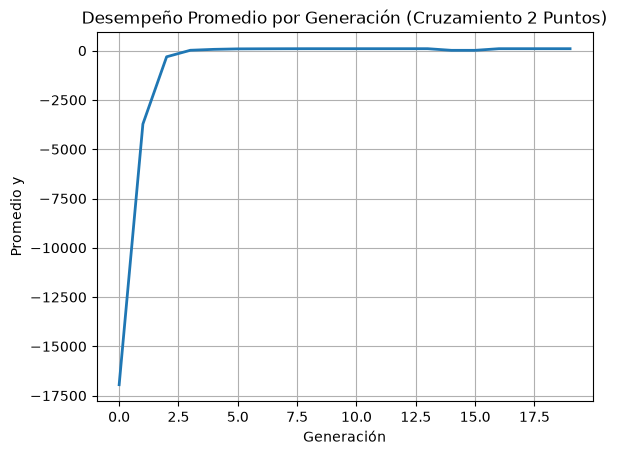

Resultado: x = 21, y = 99.6069


In [ ]:
##-Codigo_1_Cruzamiento_2_Puntos-------
import numpy as np 
import matplotlib.pyplot as plt 
# --- Iniciar la Poblacion ---
# nbit ln(256)/ln(2)=8
nbits = 8
pobladores = 200 
xpadres = np.random.randint(0, 256, pobladores)
yprom = np.zeros(20) 
# Número de generaciones
for n in range(20):
    # ---- Evaluar y ordenar y = f(x) ----
    # Función de ajuste: y = -(x-20.373)^2 + 100
    y = -(xpadres - 20.373)**2 + 100
    yprom[n] = np.mean(y)

    # Crear los cromosomas (ordenando de menor a mayor según y)
    indicies_ordenas = np.argsort(y)
    xpadres_ordenados = xpadres[indicies_ordenas]

    # Nos quedamos con la mitad superior (los mejores evaluados)
    mejores_padres = xpadres_ordenados[pobladores // 2 :]

    # --- Decodificar a binario ---
    # Convertimos los números decimales a binario (8 columnas)
    padresbin = np.zeros((pobladores // 2, nbits), dtype=int)
    for i, val in enumerate(mejores_padres):
        for j in range(nbits):
            padresbin[i, j] = (int(val) >> j) & 1

    # --- Cruzamiento de dos puntos  ---
    hijobin = np.zeros_like(padresbin) 

    for k in range(pobladores // 4):
        # Elegir 2 puntos de corte distintos entre 1 y nbits-1, y ordenarlos
        puntos = sorted(np.random.choice(range(1, nbits), 2, replace=False))
        m1, m2 = puntos[0], puntos[1]

        padre1 = padresbin[2*k]
        padre2 = padresbin[2*k + 1]

        # Cruzamiento intercambiando la parte central (entre m1 y m2)
        hijobin[2*k] = np.concatenate((padre1[:m1], padre2[m1:m2], padre1[m2:]))
        hijobin[2*k + 1] = np.concatenate((padre2[:m1], padre1[m1:m2], padre2[m2:]))

    # --- Mutación ---
    p = np.random.rand()
    if p >= 0.8:
        # Seleccionar aleatoriamente una posición y un bit
        nhijo = np.random.randint(0, pobladores // 2)
        nbit = np.random.randint(0, nbits)

        # Invertir bit: si es 1 cambia a 0, y viceversa
        hijobin[nhijo, nbit] = 1 - hijobin[nhijo, nbit]

    # --- Reemplazo --- 
    # Cambiar binario a decimal
    hijodec = np.zeros(pobladores // 2) 
    for i in range(pobladores // 2):
        val = 0
        for j in range(nbits):
            val += hijobin[i,j] * (2**j)
        hijodec[i] = val 

    # Anexar el nuevo hijo decimal a los xpadres
    xpadres = np.concatenate((mejores_padres, hijodec)).astype(int)
    # --- Mostrar solución en pantalla ---
# Evaluar función final 
y = -(xpadres - 20.373)**2 + 100 

# Graficar el promedio 
plt.plot(yprom, linewidth=2)
plt.title('Desempeño Promedio por Generación (Cruzamiento 2 Puntos)')
plt.xlabel('Generación')
plt.ylabel('Promedio y')
plt.grid(True)
plt.show()

# Ubicar el máximo 
val = np.max(y)
ind = np.argmax(y)

print(f"Resultado: x = {xpadres[ind]}, y = {val:.4f}")



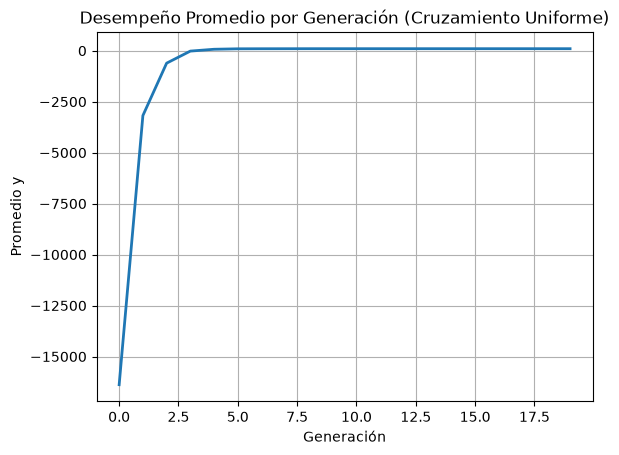

Resultado: x = 19, y = 98.1149


In [10]:
##-Codigo_1_Cruzamiento_Uniforme-------
import numpy as np 
import matplotlib.pyplot as plt 

# --- Iniciar la Población ---
# nbit ln(256)/ln(2)=8
nbits = 8
pobladores = 200 # Poblacion inical 
xpadres = np.random.randint(0, 256, pobladores)
yprom = np.zeros(20) # Para guardar el promedio de las 20 generaciones

# Número de generaciones
for n in range(20):
    # ---- Evaluar y ordenar y = f(x) ----
    # Función de ajuste: y = -(x-20.373)^2 + 100
    y = -(xpadres - 20.373)**2 + 100
    yprom[n] = np.mean(y)

    # Crear los cromosomas (ordenando de menor a mayor según y)
    indicies_ordenas = np.argsort(y)
    xpadres_ordenados = xpadres[indicies_ordenas]

    # Nos quedamos con la mitad superior (los mejores evaluados)
    mejores_padres = xpadres_ordenados[pobladores // 2 :]

    # --- Decodificar a binario ---
    # Convertimos los números decimales a binario (8 columnas)
    padresbin = np.zeros((pobladores // 2, nbits), dtype=int)
    for i, val in enumerate(mejores_padres):
        for j in range(nbits):
            padresbin[i, j] = (int(val) >> j) & 1

    # --- Cruzamiento UNIFORME ---
    hijobin = np.zeros_like(padresbin) 

    for k in range(pobladores // 4):
        padre1 = padresbin[2*k]
        padre2 = padresbin[2*k + 1]

        # Crear una máscara aleatoria de 0s y 1s del tamaño de los bits
        mascara = np.random.randint(0, 2, nbits)

        # Usamos np.where para elegir de qué padre viene cada bit
        hijobin[2*k] = np.where(mascara == 1, padre1, padre2)
        hijobin[2*k + 1] = np.where(mascara == 1, padre2, padre1)

    # --- Mutación ---
    p = np.random.rand()
    if p >= 0.8:
        # Seleccionar aleatoriamente una posición y un bit
        nhijo = np.random.randint(0, pobladores // 2)
        nbit = np.random.randint(0, nbits)

        # Invertir bit: si es 1 cambia a 0, y viceversa
        hijobin[nhijo, nbit] = 1 - hijobin[nhijo, nbit]

    # --- Reemplazo --- 
    # Cambiar binario a decimal
    hijodec = np.zeros(pobladores // 2) 
    for i in range(pobladores // 2):
        val = 0
        for j in range(nbits):
            val += hijobin[i,j] * (2**j)
        hijodec[i] = val 

    # Anexar el nuevo hijo decimal a los xpadres
    xpadres = np.concatenate((mejores_padres, hijodec)).astype(int)

# --- Mostrar solución en pantalla ---
# Evaluar función final 
y = -(xpadres - 20.373)**2 + 100 

# Graficar el promedio 
plt.plot(yprom, linewidth=2)
plt.title('Desempeño Promedio por Generación (Cruzamiento Uniforme)')
plt.xlabel('Generación')
plt.ylabel('Promedio y')
plt.grid(True)
plt.show()

# Ubicar el máximo 
val = np.max(y)
ind = np.argmax(y)

print(f"Resultado: x = {xpadres[ind]}, y = {val:.4f}")

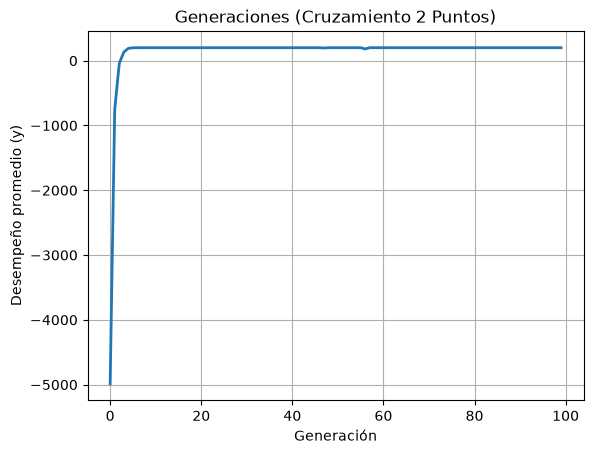

Resultado: x=41.1603, y=199.9988


In [11]:
##-Codigo_1_Cruzamiento_2_Puntos-------
import numpy as np
import matplotlib.pyplot as plt

#-------- inicializacion de la poblacion -------
# definicion de limites y tamaño de paso
xmin = -100 # limite inferior
xmax = 100 # limite superior
tpaso = 0.01 # tamaño de paso

# calculo de elemento y numero de bits
elementos = (xmax-xmin)/tpaso+1 # numero de elementos
nbits = int(np.ceil(np.log2(elementos))) # numero de bits
num_poblacion = 512 # tamaño de poblacion

# padres enteros a padres reales
# generar poblacion inicial de enteros
x1 = np.random.randint(0, 2**nbits, num_poblacion)

# transformar de enteros a reales
x1real = (xmax-xmin)*x1 / (2**nbits-1) + xmin

# matriz para almacenar el promedio del desempeño
yprom = np.zeros(100) # zeros crea una matriz de puros 0

#------- iniciar numero de generaciones -------
for i in range(100):
    # evaluar los padres de la funcion objetivo
    y = -(x1real-41.125)**2 + 200 # funcion de fitness
    yprom[i] = np.mean(y)

    # ordenar los cromosomas (de menor a mayor desempeño)
    indices_ordenados = np.argsort(y)
    x1_ordenado = x1[indices_ordenados]
    x1real_ordenado = x1real[indices_ordenados]

    # seleccionar la mitad (los mejores)
    mejores_x1 = x1_ordenado[num_poblacion//2:]
    mejores_x1real = x1real_ordenado[num_poblacion//2:]

    # convertir padres enteros seleccionados a binario
    padresbin = np.zeros((num_poblacion//2, nbits), dtype=int)
    for idx, val in enumerate(mejores_x1):
        for j in range(nbits):
            padresbin[idx, j] = (int(val) >> j) & 1

    #-------- cruzamiento de DOS PUNTOS -----
    hijobin = np.zeros_like(padresbin)

    for k in range(num_poblacion//4):
        # elegir 2 puntos de corte distintos
        puntos = sorted(np.random.choice(range(1, nbits), 2, replace=False))
        m1, m2 = puntos[0], puntos[1]

        padre1 = padresbin[2*k]
        padre2 = padresbin[2*k+1]

        # intercambiar informacion para crear hijos binarios
        hijobin[2*k] = np.concatenate((padre1[:m1], padre2[m1:m2], padre1[m2:]))
        hijobin[2*k+1] = np.concatenate((padre2[:m1], padre1[m1:m2], padre2[m2:]))

    #-------- mutacion--------
    p = np.random.rand() # definimos un numero aleatorio entre 0 y 1

    if p > 0.90: # condicion para mutacion (10%)
        # seleccionar aleatoriamente una posicion y un bit
        nhijo = np.random.randint(0, num_poblacion//2)
        nbit = np.random.randint(0, nbits)
        # invertir el valor del bit
        hijobin[nhijo, nbit] = 1 - hijobin[nhijo, nbit]

    # ---- reiniciar proceso (decodificacion)----
    # convertir hijo binario a entero
    hijoent = np.zeros(num_poblacion//2)
    for idx in range(num_poblacion//2):
        val = 0
        for j in range(nbits):
            val += hijobin[idx, j] * (2**j)
        hijoent[idx] = val

    # convertir hijo entero a real usando la funcion de conversacion
    hijoreal = (xmax-xmin)*hijoent/(2**nbits-1) + xmin

    # actualizar matrices pasandolo de hijo a padre
    x1 = np.concatenate((mejores_x1, hijoent))
    x1real = np.concatenate((mejores_x1real, hijoreal))

#------- mostrar resultado en pantalla ------
plt.plot(yprom, linewidth=2)
plt.title("Generaciones (Cruzamiento 2 Puntos)")
plt.xlabel("Generación")
plt.ylabel("Desempeño promedio (y)")
plt.grid(True)
plt.show()

# evaluar la funcion final para encontrar el maximo
y = -(x1real-41.125)**2 + 200
val = np.max(y)
ind = np.argmax(y)

print(f"Resultado: x={x1real[ind]:.4f}, y={val:.4f}")

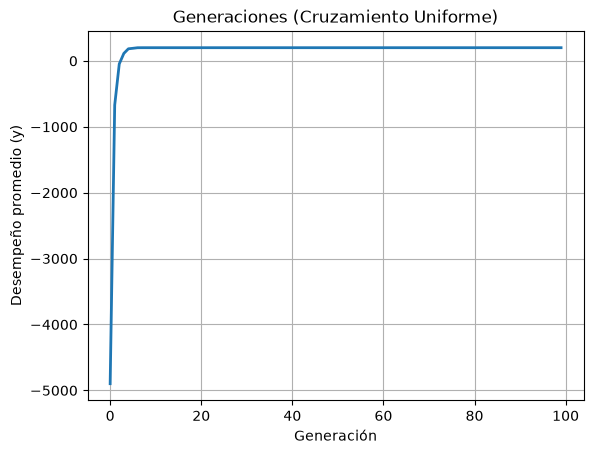

Resultado: x=41.1115, y=199.9998


In [12]:
##-Codigo_2_Cruzamiento_Uniforme-------
import numpy as np
import matplotlib.pyplot as plt

#-------- inicializacion de la poblacion -------
# definicion de limites y tamaño de paso
xmin = -100 # limite inferior
xmax = 100 # limite superior
tpaso = 0.01 # tamaño de paso

# calculo de elemento y numero de bits
elementos = (xmax-xmin)/tpaso+1 # numero de elementos
nbits = int(np.ceil(np.log2(elementos))) # numero de bits
num_poblacion = 512 # tamaño de poblacion

# padres enteros a padres reales
# generar poblacion inicial de enteros
x1 = np.random.randint(0, 2**nbits, num_poblacion)

# transformar de enteros a reales
x1real = (xmax-xmin)*x1 / (2**nbits-1) + xmin

# matriz para almacenar el promedio del desempeño
yprom = np.zeros(100) # zeros crea una matriz de puros 0

#------- iniciar numero de generaciones -------
for i in range(100):
    # evaluar los padres de la funcion objetivo
    y = -(x1real-41.125)**2 + 200 # funcion de fitness
    yprom[i] = np.mean(y)

    # ordenar los cromosomas (de menor a mayor desempeño)
    indices_ordenados = np.argsort(y)
    x1_ordenado = x1[indices_ordenados]
    x1real_ordenado = x1real[indices_ordenados]

    # seleccionar la mitad (los mejores)
    mejores_x1 = x1_ordenado[num_poblacion//2:]
    mejores_x1real = x1real_ordenado[num_poblacion//2:]

    # convertir padres enteros seleccionados a binario
    padresbin = np.zeros((num_poblacion//2, nbits), dtype=int)
    for idx, val in enumerate(mejores_x1):
        for j in range(nbits):
            padresbin[idx, j] = (int(val) >> j) & 1

    #-------- cruzamiento UNIFORME -----
    hijobin = np.zeros_like(padresbin)

    for k in range(num_poblacion//4):
        padre1 = padresbin[2*k]
        padre2 = padresbin[2*k+1]

        # Crear una máscara aleatoria de 0s y 1s
        mascara = np.random.randint(0, 2, nbits)

        # Usamos la máscara para elegir de qué padre viene cada bit
        hijobin[2*k] = np.where(mascara == 1, padre1, padre2)
        hijobin[2*k+1] = np.where(mascara == 1, padre2, padre1)

    #-------- mutacion--------
    p = np.random.rand() # definimos un numero aleatorio entre 0 y 1

    if p > 0.90: # condicion para mutacion (10%)
        # seleccionar aleatoriamente una posicion y un bit
        nhijo = np.random.randint(0, num_poblacion//2)
        nbit = np.random.randint(0, nbits)
        # invertir el valor del bit
        hijobin[nhijo, nbit] = 1 - hijobin[nhijo, nbit]

    # ---- reiniciar proceso (decodificacion)----
    # convertir hijo binario a entero
    hijoent = np.zeros(num_poblacion//2)
    for idx in range(num_poblacion//2):
        val = 0
        for j in range(nbits):
            val += hijobin[idx, j] * (2**j)
        hijoent[idx] = val

    # convertir hijo entero a real usando la funcion de conversacion
    hijoreal = (xmax-xmin)*hijoent/(2**nbits-1) + xmin

    # actualizar matrices pasandolo de hijo a padre
    x1 = np.concatenate((mejores_x1, hijoent))
    x1real = np.concatenate((mejores_x1real, hijoreal))

#------- mostrar resultado en pantalla ------
plt.plot(yprom, linewidth=2)
plt.title("Generaciones (Cruzamiento Uniforme)")
plt.xlabel("Generación")
plt.ylabel("Desempeño promedio (y)")
plt.grid(True)
plt.show()

# evaluar la funcion final para encontrar el maximo
y = -(x1real-41.125)**2 + 200
val = np.max(y)
ind = np.argmax(y)

print(f"Resultado: x={x1real[ind]:.4f}, y={val:.4f}")
